# 04. Sparkov Past-Only Behavioral Features

This notebook extends the current-transaction baseline by adding **behavioral features calculated only from transactions that occurred before the current transaction**.

The main purpose is to test whether historical card and merchant behavior improves future fraud detection without introducing temporal leakage.

## Main Research Question

> Do leakage-safe past-only behavioral features improve Validation performance beyond the current-transaction LightGBM baseline?

## Core Rule

For transaction \(t\), every historical feature must be computed using only transactions that occurred **before \(t\)**.

The current transaction must not be included in its own historical statistics, and future transactions must never affect past rows.

## What This Notebook Adds

Card-level history:

- number of previous transactions
- time since previous transaction
- historical mean and standard deviation of transaction amount
- current amount relative to historical amount
- whether the merchant is new for the card
- number of distinct merchants previously seen
- whether the category is new for the card
- number of distinct categories previously seen

Merchant-level history:

- number of previous transactions at the merchant
- historical merchant transaction amount mean

## Experimental Design

Two LightGBM models are compared using the **same model settings**:

1. current-transaction features only
2. current-transaction features + past-only behavioral features

Using the same model structure isolates the effect of the historical features.

## Test Set Lock

The final Test period remains untouched in this notebook.

All development comparisons are made on Validation only.

## 1. Import Libraries and Create Output Folders

This notebook is designed to run independently in Kaggle.

The first cell imports the required libraries and creates the standard project output folders.

In [5]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    precision_recall_curve,
)

from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load the Sparkov Dataset

The Sparkov dataset used in this project is loaded directly from Kaggle.

Expected path:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

In [6]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
display(df.head())

Raw shape: (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


## 3. Basic Cleaning

We repeat the same cleaning used in the previous notebooks so this notebook can reproduce its own analysis.

Steps:

- remove accidental `Unnamed` index columns
- convert transaction time and date of birth to datetime
- remove the synthetic `fraud_` prefix from merchant names
- sort every transaction chronologically

Sorting before feature construction is essential because the historical features depend on transaction order.

In [7]:
unnamed_cols = [
    col for col in df.columns
    if col.lower().startswith("unnamed")
]

df = df.drop(
    columns=unnamed_cols,
    errors="ignore"
)

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .str.replace(r"^fraud_", "", regex=True)
)

df = (
    df.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Clean shape:", df.shape)
print(
    "Period:",
    df["trans_date_trans_time"].min(),
    "to",
    df["trans_date_trans_time"].max()
)
print("Fraud rate:", df["is_fraud"].mean())

Clean shape: (1296675, 24)
Period: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Fraud rate: 0.005788651743883394


## 4. Recreate the Current-Transaction Features

To make the comparison fair, we use the same current-transaction features as Notebook 03.

These features are available at transaction time and do not require transaction history.

They include:

- amount
- city population
- age
- home-to-merchant distance
- hour and day-of-week information

In [8]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days
    / 365.25
)

df["distance_home_to_merchant_km"] = haversine_km(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

print("Current-transaction features created.")

Current-transaction features created.


## 5. Why Past-Only Features Matter

Suppose one card has these transactions:

| Time | Amount |
|---|---:|
| 10:00 | 20 |
| 11:00 | 40 |
| 12:00 | 300 |

When predicting the 12:00 transaction, the historical mean should be:

\[
(20 + 40) / 2 = 30
\]

It must **not** include the current 300-dollar transaction.

Including the current row would make the historical feature partly describe the answer we are trying to predict.

Including a future row would be even more serious temporal leakage.

This notebook therefore constructs cumulative statistics that always exclude the current transaction.

## 6. Create Leakage-Safe Past-Only Features

The following function processes the transaction stream in chronological order.

### Important implementation ideas

- `cumcount()` counts only rows that appeared earlier within each group.
- cumulative sums are calculated and then the current amount is subtracted.
- the current transaction is never included in its own historical mean.
- no fraud label is used in any historical feature.

Because these features use **transaction attributes rather than historical fraud labels**, transactions in the chronological history can contribute to later features even when they are not part of the model-training sample.

That matches a real-time setting in which prior transaction activity is observable when a later transaction arrives.

In [9]:
def add_past_only_features(data):
    data = (
        data.sort_values(
            ["unix_time", "trans_num"]
        )
        .reset_index(drop=True)
        .copy()
    )

    # --------------------------------------------------
    # 1. Card-level transaction history
    # --------------------------------------------------
    card_group = data.groupby(
        "cc_num",
        sort=False
    )

    data["card_tx_count_before"] = (
        card_group.cumcount()
    )

    data["card_has_history"] = (
        data["card_tx_count_before"] > 0
    ).astype("int8")

    data["card_prev_unix_time"] = (
        card_group["unix_time"]
        .shift(1)
    )

    data["card_time_since_prev_hours"] = (
        data["unix_time"]
        - data["card_prev_unix_time"]
    ) / 3600.0

    # --------------------------------------------------
    # 2. Card-level amount history
    # --------------------------------------------------
    data["_amt_sq"] = (
        data["amt"] ** 2
    )

    data["_card_amt_sum_before"] = (
        card_group["amt"].cumsum()
        - data["amt"]
    )

    data["_card_amt_sq_sum_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_amt_sq"].cumsum()
        - data["_amt_sq"]
    )

    previous_count = (
        data["card_tx_count_before"]
        .replace(0, np.nan)
    )

    data["card_amt_mean_before"] = (
        data["_card_amt_sum_before"]
        / previous_count
    )

    previous_second_moment = (
        data["_card_amt_sq_sum_before"]
        / previous_count
    )

    previous_variance = (
        previous_second_moment
        - data["card_amt_mean_before"] ** 2
    ).clip(lower=0)

    data["card_amt_std_before"] = (
        np.sqrt(previous_variance)
    )

    data["card_amt_ratio_to_mean"] = (
        data["amt"]
        / data[
            "card_amt_mean_before"
        ].replace(0, np.nan)
    )

    data["card_amt_zscore_before"] = (
        (
            data["amt"]
            - data["card_amt_mean_before"]
        )
        / data[
            "card_amt_std_before"
        ].replace(0, np.nan)
    )

    # --------------------------------------------------
    # 3. Card-merchant history
    # --------------------------------------------------
    data["card_merchant_pair_count_before"] = (
        data.groupby(
            ["cc_num", "merchant_clean"],
            sort=False
        ).cumcount()
    )

    data["card_new_merchant"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_merchant_first_for_card"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_merchants_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_merchant_first_for_card"].cumsum()
        - data["_merchant_first_for_card"]
    )

    # --------------------------------------------------
    # 4. Card-category history
    # --------------------------------------------------
    data["card_category_pair_count_before"] = (
        data.groupby(
            ["cc_num", "category"],
            sort=False
        ).cumcount()
    )

    data["card_new_category"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_category_first_for_card"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_categories_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_category_first_for_card"].cumsum()
        - data["_category_first_for_card"]
    )

    # --------------------------------------------------
    # 5. Merchant-level transaction history
    # --------------------------------------------------
    merchant_group = data.groupby(
        "merchant_clean",
        sort=False
    )

    data["merchant_tx_count_before"] = (
        merchant_group.cumcount()
    )

    data["_merchant_amt_sum_before"] = (
        merchant_group["amt"].cumsum()
        - data["amt"]
    )

    merchant_previous_count = (
        data["merchant_tx_count_before"]
        .replace(0, np.nan)
    )

    data["merchant_amt_mean_before"] = (
        data["_merchant_amt_sum_before"]
        / merchant_previous_count
    )

    # --------------------------------------------------
    # 6. Remove temporary helper columns
    # --------------------------------------------------
    helper_cols = [
        "_amt_sq",
        "_card_amt_sum_before",
        "_card_amt_sq_sum_before",
        "_merchant_first_for_card",
        "_category_first_for_card",
        "_merchant_amt_sum_before",
    ]

    data = data.drop(
        columns=helper_cols
    )

    return data


df = add_past_only_features(df)

print("Past-only features created.")
print("Shape:", df.shape)

Past-only features created.
Shape: (1296675, 49)


## 7. Inspect the New Features

The first transaction for a card has no prior card history.

Therefore some historical values are expected to be missing:

- previous transaction time
- historical mean amount
- historical standard deviation

These missing values are meaningful and will later be handled by the model preprocessing pipeline.

A missing historical mean does **not** mean the data is corrupted. It means there was no earlier transaction for that card.

In [10]:
past_feature_preview = [
    "trans_date_trans_time",
    "cc_num",
    "merchant_clean",
    "category",
    "amt",
    "card_tx_count_before",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_amt_ratio_to_mean",
    "card_amt_zscore_before",
    "card_new_merchant",
    "card_distinct_merchants_before",
    "card_new_category",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

display(
    df[past_feature_preview].head(20)
)

,trans_date_trans_time,cc_num,merchant_clean,category,amt,card_tx_count_before,card_time_since_prev_hours,card_amt_mean_before,card_amt_std_before,card_amt_ratio_to_mean,card_amt_zscore_before,card_new_merchant,card_distinct_merchants_before,card_new_category,card_distinct_categories_before,merchant_tx_count_before,merchant_amt_mean_before
0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
5,2019-01-01 00:04:08,4767265376804500,"Stroman, Hudson and Erdman",gas_transport,94.63,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
6,2019-01-01 00:04:42,30074693890476,Rowe-Vandervort,grocery_net,44.54,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
7,2019-01-01 00:05:08,6011360759745864,Corwin-Collins,gas_transport,71.65,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
8,2019-01-01 00:05:18,4922710831011201,Herzog Ltd,misc_pos,4.27,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN
9,2019-01-01 00:06:01,2720830304681674,"Schoen, Kuphal and Nitzsche",grocery_pos,198.39,0,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0,NaN


## 8. Leakage-Safety Checks

Feature engineering code can look correct while still leaking future information.

We therefore include explicit tests.

### Check 1 — First and second transaction logic

For a card with multiple transactions:

- the first transaction should have `card_tx_count_before = 0`
- the second should have `card_tx_count_before = 1`
- the second transaction's historical mean should equal the first transaction's amount

These checks verify that the current row is excluded.

In [11]:
sample_card = (
    df["cc_num"]
    .value_counts()
    .index[0]
)

sample_card_rows = (
    df[
        df["cc_num"] == sample_card
    ]
    .sort_values(
        ["unix_time", "trans_num"]
    )
    .head(5)
    .copy()
)

display(
    sample_card_rows[
        [
            "trans_date_trans_time",
            "amt",
            "card_tx_count_before",
            "card_amt_mean_before",
            "card_time_since_prev_hours",
        ]
    ]
)

assert (
    sample_card_rows.iloc[0][
        "card_tx_count_before"
    ] == 0
)

assert (
    sample_card_rows.iloc[1][
        "card_tx_count_before"
    ] == 1
)

assert np.isclose(
    sample_card_rows.iloc[1][
        "card_amt_mean_before"
    ],
    sample_card_rows.iloc[0]["amt"]
)

print(
    "First/second transaction leakage checks passed."
)

,trans_date_trans_time,amt,card_tx_count_before,card_amt_mean_before,card_time_since_prev_hours
70,2019-01-01 00:50:53,16.16,0,NaN,NaN
365,2019-01-01 04:45:43,124.70,1,16.160000,3.913889
531,2019-01-01 06:56:09,56.50,2,70.430000,2.173889
1144,2019-01-01 13:49:05,65.96,3,65.786667,6.882222
1477,2019-01-01 16:15:08,10.24,4,65.830000,2.434167


First/second transaction leakage checks passed.


### Check 2 — Future-change invariance test

A strong leakage test is to change a future transaction and confirm that earlier historical features do not change.

We:

1. take several chronological transactions from one card
2. calculate their features
3. dramatically change the amount of the final transaction
4. calculate the features again
5. compare all earlier rows

If earlier rows change, future information is leaking backward.

In [12]:
raw_for_test = (
    pd.read_csv(DATA_PATH)
)

raw_for_test = raw_for_test.drop(
    columns=[
        c for c in raw_for_test.columns
        if c.lower().startswith("unnamed")
    ],
    errors="ignore"
)

raw_for_test[
    "trans_date_trans_time"
] = pd.to_datetime(
    raw_for_test[
        "trans_date_trans_time"
    ],
    errors="coerce"
)

raw_for_test["merchant_clean"] = (
    raw_for_test["merchant"]
    .str.replace(
        r"^fraud_",
        "",
        regex=True
    )
)

raw_for_test = (
    raw_for_test.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

test_card = (
    raw_for_test[
        "cc_num"
    ].value_counts().index[0]
)

tiny = (
    raw_for_test[
        raw_for_test["cc_num"] == test_card
    ]
    .head(8)
    .copy()
    .reset_index(drop=True)
)

features_before_change = (
    add_past_only_features(tiny)
)

tiny_changed = tiny.copy()

tiny_changed.loc[
    tiny_changed.index[-1],
    "amt"
] = (
    tiny_changed.loc[
        tiny_changed.index[-1],
        "amt"
    ]
    * 1000
    + 999999
)

features_after_change = (
    add_past_only_features(
        tiny_changed
    )
)

columns_to_compare = [
    "card_tx_count_before",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_distinct_merchants_before",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

pd.testing.assert_frame_equal(
    features_before_change.loc[
        :-2,
        columns_to_compare
    ].reset_index(drop=True),
    features_after_change.loc[
        :-2,
        columns_to_compare
    ].reset_index(drop=True),
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

print(
    "Future-change invariance test passed."
)

Future-change invariance test passed.


### Why this test is useful

The last transaction was changed by an extreme amount.

If a historical feature for an earlier row changed because of that modification, then the feature calculation would be using future information.

Because the earlier rows remain unchanged, the test supports the intended past-only design.

## 9. Recreate the Fixed Chronological Split

We now recreate the exact experimental split used in Notebook 02 and Notebook 03.

- Train: first 60%
- Calibration: next 15%
- Validation: next 10%
- Test: final 15%
- total purge window at each boundary: 24 hours

### Important detail

Past-only features were calculated on the chronological transaction stream before splitting.

This is intentional.

For a Validation transaction, earlier observed transaction activity may be used to construct its historical behavior, just as it would be available in a real-time system.

However:

- future rows are never used
- fraud labels are never used in the historical features
- preprocessing/model parameters are still fitted only on Train

The Test period remains locked.

In [13]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int(
    (PURGE_HOURS / 2) * 3600
)

n = len(df)

train_boundary_idx = int(
    n * TRAIN_RATIO
)

calibration_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
    )
)

validation_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
        + VALIDATION_RATIO
    )
)

train_boundary = int(
    df.iloc[
        train_boundary_idx
    ]["unix_time"]
)

calibration_boundary = int(
    df.iloc[
        calibration_boundary_idx
    ]["unix_time"]
)

validation_boundary = int(
    df.iloc[
        validation_boundary_idx
    ]["unix_time"]
)

train = df[
    df["unix_time"]
    < (
        train_boundary
        - HALF_PURGE_SECONDS
    )
].copy()

calibration = df[
    (
        df["unix_time"]
        > (
            train_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            calibration_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

validation = df[
    (
        df["unix_time"]
        > (
            calibration_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            validation_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

test = df[
    df["unix_time"]
    > (
        validation_boundary
        + HALF_PURGE_SECONDS
    )
].copy()

assert (
    train["unix_time"].max()
    < calibration[
        "unix_time"
    ].min()
)

assert (
    calibration[
        "unix_time"
    ].max()
    < validation[
        "unix_time"
    ].min()
)

assert (
    validation[
        "unix_time"
    ].max()
    < test["unix_time"].min()
)

print(
    {
        "train": len(train),
        "calibration": len(calibration),
        "validation": len(validation),
        "test": len(test),
    }
)

{'train': 777050, 'calibration': 192249, 'validation': 128128, 'test': 193574}


## 10. Define Current and Past-Only Feature Sets

The **current-only model** reproduces the LightGBM feature set from Notebook 03.

The **past-only model** uses exactly the same current features plus the new behavioral history.

This ensures that the comparison answers one specific question:

> What additional value comes from historical behavior?

In [14]:
current_numeric_features = [
    "amt",
    "city_pop",
    "age",
    "distance_home_to_merchant_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

categorical_features = [
    "category",
    "merchant_clean",
    "state",
    "job",
]

past_only_numeric_features = [
    "card_tx_count_before",
    "card_has_history",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_amt_ratio_to_mean",
    "card_amt_zscore_before",
    "card_merchant_pair_count_before",
    "card_new_merchant",
    "card_distinct_merchants_before",
    "card_category_pair_count_before",
    "card_new_category",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

current_feature_cols = (
    current_numeric_features
    + categorical_features
)

past_feature_cols = (
    current_numeric_features
    + past_only_numeric_features
    + categorical_features
)

print(
    "Current-only feature count:",
    len(current_feature_cols)
)

print(
    "Current + past-only feature count:",
    len(past_feature_cols)
)

Current-only feature count: 15
Current + past-only feature count: 30


## 11. Inspect Missingness in Historical Features

Historical features naturally contain missing values for entities with no prior history.

For example:

- first card transaction → no previous transaction time
- first merchant transaction → no historical merchant amount mean
- only one previous card transaction → historical standard deviation may be zero or undefined

The model pipeline handles these values using **Train-fitted median imputation**.

In [15]:
past_missing = (
    train[
        past_only_numeric_features
    ]
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .rename(
        "missing_rate"
    )
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)

display(past_missing)

past_missing.to_csv(
    "/kaggle/working/results/"
    "past_only_feature_missingness.csv",
    index=False
)

,feature,missing_rate
0,card_amt_zscore_before,0.002077
1,card_amt_mean_before,0.001225
2,card_time_since_prev_hours,0.001225
3,card_amt_std_before,0.001225
4,card_amt_ratio_to_mean,0.001225
5,merchant_amt_mean_before,0.000892
6,card_has_history,0.000000
7,card_tx_count_before,0.000000
8,card_merchant_pair_count_before,0.000000
9,card_distinct_merchants_before,0.000000


## 12. Define the LightGBM Preprocessing Pipeline

To isolate the feature effect, both models use the same preprocessing design and LightGBM hyperparameters.

### Numerical variables

- median imputation

### Categorical variables

- most-frequent imputation
- ordinal encoding
- unseen Validation categories receive code `-1`

All preprocessing is fitted on Train only.

No imputation or encoding rule is learned from Validation or Test.

In [16]:
def make_lgbm_pipeline(
    numeric_features,
    categorical_features
):
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown=(
                    "use_encoded_value"
                ),
                unknown_value=-1
            )
        ),
    ])

    preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
    ])

    model = LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1
    )

    return Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        ),
    ])

## 13. Define Evaluation Metrics

As in Notebook 03:

- **PR-AUC** is the primary ranking metric
- ROC-AUC is secondary
- Precision, Recall, and F1 are shown at threshold 0.5 only as references
- Brier Score and Log Loss describe probability quality
- Fraud Amount Recall measures the share of total fraud transaction amount captured

The 0.5 threshold is **not** the final operational policy.

Threshold optimization is postponed to the cost-sensitive stage.

In [17]:
def fraud_amount_recall(
    y_true,
    pred,
    amount
):
    y = np.asarray(y_true)
    pred = np.asarray(pred)
    amount = np.asarray(amount)

    total_fraud_amount = (
        amount[y == 1].sum()
    )

    if total_fraud_amount == 0:
        return np.nan

    detected_amount = (
        amount[
            (y == 1)
            & (pred == 1)
        ].sum()
    )

    return (
        detected_amount
        / total_fraud_amount
    )


def evaluate_model(
    model_name,
    y_true,
    proba,
    amount,
    threshold=0.5
):
    proba = np.asarray(proba)

    pred = (
        proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            pred,
            labels=[0, 1]
        ).ravel()
    )

    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(
            y_true,
            proba
        ),
        "pr_auc": average_precision_score(
            y_true,
            proba
        ),
        "precision": precision_score(
            y_true,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            pred,
            zero_division=0
        ),
        "brier": brier_score_loss(
            y_true,
            proba
        ),
        "log_loss": log_loss(
            y_true,
            np.clip(
                proba,
                1e-8,
                1 - 1e-8
            )
        ),
        "alert_rate": pred.mean(),
        "fraud_amount_recall": (
            fraud_amount_recall(
                y_true,
                pred,
                amount
            )
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

## 14. Train the Current-Only LightGBM

This model reproduces the current-transaction baseline under the same pipeline used for the historical-feature comparison.

Only Train is used for fitting.

Validation is used for development evaluation.

In [18]:
current_model = make_lgbm_pipeline(
    current_numeric_features,
    categorical_features
)

current_model.fit(
    train[
        current_feature_cols
    ],
    train["is_fraud"]
)

current_val_proba = (
    current_model.predict_proba(
        validation[
            current_feature_cols
        ]
    )[:, 1]
)

current_metrics = evaluate_model(
    "LightGBM - current only",
    validation["is_fraud"],
    current_val_proba,
    validation["amt"]
)

current_metrics

{'model': 'LightGBM - current only',
 'threshold': 0.5,
 'roc_auc': np.float64(0.9973359398266124),
 'pr_auc': np.float64(0.8954524971639761),
 'precision': 0.9426356589147287,
 'recall': 0.7212336892052195,
 'f1': 0.8172043010752689,
 'brier': np.float64(0.0017066741728083222),
 'log_loss': 0.007091870734202216,
 'alert_rate': np.float64(0.005034028471528472),
 'fraud_amount_recall': np.float64(0.78739044001073),
 'true_negative': 127248,
 'false_positive': 37,
 'false_negative': 235,
 'true_positive': 608}

## 15. Train the Current + Past-Only LightGBM

This model uses the same LightGBM settings but adds the historical behavioral features.

Any improvement should therefore be interpreted as evidence that the past-only features add useful information on the Validation period.

In [19]:
past_model = make_lgbm_pipeline(
    (
        current_numeric_features
        + past_only_numeric_features
    ),
    categorical_features
)

past_model.fit(
    train[
        past_feature_cols
    ],
    train["is_fraud"]
)

past_val_proba = (
    past_model.predict_proba(
        validation[
            past_feature_cols
        ]
    )[:, 1]
)

past_metrics = evaluate_model(
    "LightGBM - current + past-only",
    validation["is_fraud"],
    past_val_proba,
    validation["amt"]
)

past_metrics

{'model': 'LightGBM - current + past-only',
 'threshold': 0.5,
 'roc_auc': np.float64(0.9980606657396504),
 'pr_auc': np.float64(0.9285856407042714),
 'precision': 0.978125,
 'recall': 0.7425860023724793,
 'f1': 0.8442346594740391,
 'brier': np.float64(0.001520703782856595),
 'log_loss': 0.006812056854768433,
 'alert_rate': np.float64(0.004995004995004995),
 'fraud_amount_recall': np.float64(0.8098884198255863),
 'true_negative': 127271,
 'false_positive': 14,
 'false_negative': 217,
 'true_positive': 626}

## 16. Compare Validation Performance

The most important comparison is the change in Validation PR-AUC.

We also examine:

- ROC-AUC
- Brier Score
- Recall
- Precision
- Fraud Amount Recall

### Interpretation principle

A higher score is meaningful only if it comes from information that would truly have been available before the transaction.

That is why the leakage tests earlier in this notebook are as important as the model metrics themselves.

In [20]:
feature_comparison = pd.DataFrame([
    current_metrics,
    past_metrics,
])

feature_comparison = (
    feature_comparison
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_comparison)

pr_auc_current = (
    feature_comparison.loc[
        feature_comparison["model"]
        == "LightGBM - current only",
        "pr_auc"
    ].iloc[0]
)

pr_auc_past = (
    feature_comparison.loc[
        feature_comparison["model"]
        == "LightGBM - current + past-only",
        "pr_auc"
    ].iloc[0]
)

print(
    "PR-AUC difference (past-only minus current):",
    pr_auc_past - pr_auc_current
)

,model,threshold,roc_auc,pr_auc,precision,recall,f1,brier,log_loss,alert_rate,fraud_amount_recall,true_negative,false_positive,false_negative,true_positive
0,LightGBM - current + past-only,0.5,0.998061,0.928586,0.978125,0.742586,0.844235,0.001521,0.006812,0.004995,0.809888,127271,14,217,626
1,LightGBM - current only,0.5,0.997336,0.895452,0.942636,0.721234,0.817204,0.001707,0.007092,0.005034,0.787390,127248,37,235,608


PR-AUC difference (past-only minus current): 0.033133143540295285


## 17. Precision-Recall Curves

The Precision-Recall curve provides a visual comparison across possible thresholds.

If the past-only model's curve is generally above the current-only curve, then the historical features improve fraud ranking over a range of operating points rather than at only one threshold.

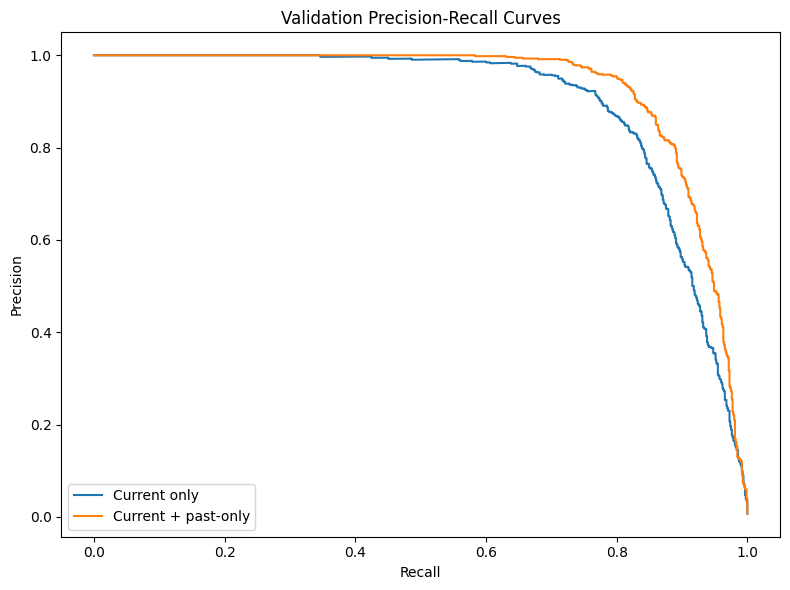

In [21]:
plt.figure(
    figsize=(8, 6)
)

for name, proba in [
    (
        "Current only",
        current_val_proba
    ),
    (
        "Current + past-only",
        past_val_proba
    ),
]:
    precision, recall, _ = (
        precision_recall_curve(
            validation["is_fraud"],
            proba
        )
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Validation Precision-Recall Curves"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "current_vs_past_only_pr_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 18. PR-AUC Comparison Figure

This compact chart makes the improvement or deterioration from historical features easy to see.

The result should be interpreted on Validation only.

The Test period remains untouched.

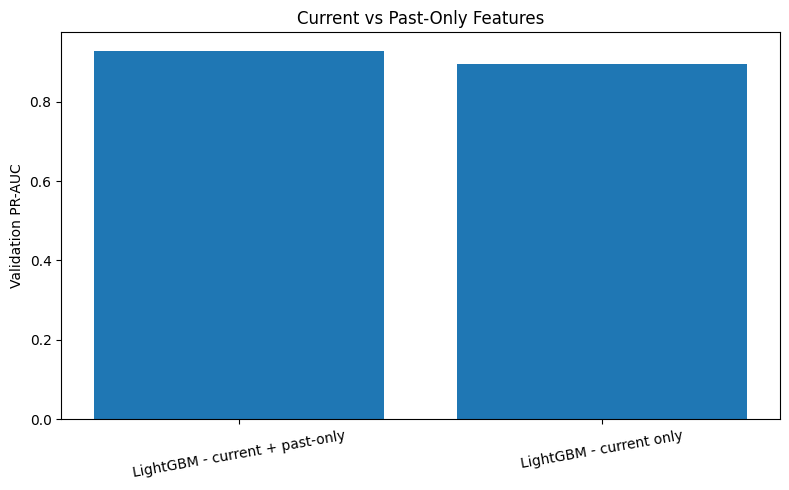

In [22]:
plot_data = feature_comparison[
    [
        "model",
        "pr_auc"
    ]
].copy()

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    plot_data["model"],
    plot_data["pr_auc"]
)

plt.ylabel(
    "Validation PR-AUC"
)

plt.title(
    "Current vs Past-Only Features"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "current_vs_past_only_pr_auc.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 19. Save the Feature List

Saving the exact feature list improves reproducibility.

Later notebooks can see exactly which variables were classified as current-transaction features and which were historical features.

In [23]:
feature_list = pd.DataFrame({
    "feature": (
        current_feature_cols
        + past_only_numeric_features
    ),
    "feature_group": (
        ["current"] * len(
            current_feature_cols
        )
        + ["past_only"] * len(
            past_only_numeric_features
        )
    )
})

feature_list = (
    feature_list
    .drop_duplicates(
        subset=["feature"]
    )
    .reset_index(drop=True)
)

display(feature_list)

feature_list.to_csv(
    "/kaggle/working/results/"
    "past_only_feature_list.csv",
    index=False
)

,feature,feature_group
0,amt,current
1,city_pop,current
2,age,current
3,distance_home_to_merchant_km,current
4,hour,current
5,day_of_week,current
6,is_weekend,current
7,hour_sin,current
8,hour_cos,current
9,dow_sin,current


## 20. Save Validation Predictions

We save the probabilities from both models so later analyses can audit the comparison without rerunning this notebook.

No Test predictions are saved here.

In [24]:
validation_predictions = validation[
    [
        "trans_num",
        "trans_date_trans_time",
        "cc_num",
        "merchant_clean",
        "is_fraud",
        "amt",
    ]
].copy()

validation_predictions[
    "current_only_probability"
] = current_val_proba

validation_predictions[
    "past_only_probability"
] = past_val_proba

display(
    validation_predictions.head()
)

,trans_num,trans_date_trans_time,cc_num,merchant_clean,is_fraud,amt,current_only_probability,past_only_probability
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,30234966027947,Hamill-Daugherty,0,64.48,0.000020,0.000001
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,30044330818990,Herzog Ltd,0,105.47,0.000170,0.000029
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,4464457352619,"Christiansen, Goyette and Schamberger",0,78.15,0.000025,0.000002
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,377993105397617,Friesen-Stamm,0,64.90,0.000007,0.000007
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,4169388510116,Prohaska-Murray,0,60.89,0.000031,0.000003


## 21. Save Results

This notebook saves the following project artifacts.

### Results

- `past_only_feature_metrics.csv`
- `past_only_feature_list.csv`
- `past_only_feature_missingness.csv`
- `past_only_validation_predictions.csv`

### Figures

- `current_vs_past_only_pr_curve.png`
- `current_vs_past_only_pr_auc.png`

In [25]:
feature_comparison.to_csv(
    "/kaggle/working/results/"
    "past_only_feature_metrics.csv",
    index=False
)

validation_predictions.to_csv(
    "/kaggle/working/results/"
    "past_only_validation_predictions.csv",
    index=False
)

print(
    "Results:",
    os.listdir(
        "/kaggle/working/results"
    )
)

print(
    "\nFigures:",
    os.listdir(
        "/kaggle/working/figures"
    )
)

Results: ['past_only_validation_predictions.csv', 'past_only_feature_list.csv', 'past_only_feature_missingness.csv', 'past_only_feature_metrics.csv']

Figures: ['current_vs_past_only_pr_auc.png', 'current_vs_past_only_pr_curve.png']


## 22. How to Interpret the Final Comparison

The comparison should be interpreted as follows.

### If PR-AUC increases

The behavioral history provides useful additional ranking information beyond the current transaction.

### If PR-AUC stays similar

The current transaction may already contain most of the available signal, or the historical features may need refinement.

### If PR-AUC decreases

Historical features are not automatically beneficial.

Possible reasons include:

- noisy history
- weak simulator behavior
- missing-history effects
- overly broad aggregation
- model complexity

A decrease should not be hidden. It is still a valid project result.

### Brier Score

If ranking improves but Brier Score worsens, the model may rank fraud better while producing less reliable probabilities.

Probability calibration is handled later.

## 23. Leakage and Methodology Notes

This notebook follows several important leakage-safety rules.

### What is allowed

For a transaction at time \(t\):

- transactions before \(t\)
- current transaction attributes available at \(t\)

### What is not allowed

- transactions after \(t\)
- current transaction included in its own historical average
- future fraud labels
- preprocessing fitted on Validation or Test
- resampling Validation or Test

### Historical labels

This first behavioral-feature version deliberately avoids label-based history such as:

- previous fraud count
- previous confirmed fraud rate

In a real bank, fraud labels may arrive with delay.

Avoiding historical labels keeps this notebook's time-availability assumption simpler and more defensible.

## 24. Limitations

### Sparkov is synthetic

The behavioral relationships in this dataset are generated by a simulator.

An improvement in past-only features should therefore be described as:

> evidence that the leakage-safe historical feature framework is useful on Sparkov

not:

> proof that the same feature has the same effect in a real bank.

### Purge-period transaction history

Transactions inside purge windows are excluded from model evaluation but may still contribute to later past-only transaction-history features because they occurred earlier in time and their transaction attributes would have been observable.

No fraud labels from those transactions are used.

### Entity cold start

A card or merchant with no history naturally has missing historical statistics.

Later evaluation should separately inspect seen and unseen entities where appropriate.

### Categorical encoding

The LightGBM baseline uses Train-fitted ordinal encoding for consistency with Notebook 03.

This is a practical baseline rather than the only possible categorical modeling approach.

## Conclusion

This notebook created and validated leakage-safe historical behavioral features for the Sparkov transaction stream.

The workflow:

1. sorted transactions chronologically
2. created current-transaction features
3. created card- and merchant-level past-only features
4. verified that current and future transactions do not affect prior historical features
5. recreated the fixed temporal development split
6. fitted preprocessing on Train only
7. compared identical LightGBM models with and without historical behavior
8. evaluated both models on Validation only
9. saved reproducible metrics, predictions, feature lists, and figures

The Test period remained untouched.

## Next Notebook

`05_sparkov_imbalance.ipynb`

The next step will compare class-imbalance strategies such as:

- no special weighting
- class weighting
- Train-only random undersampling

The goal is to determine whether imbalance handling improves fraud ranking without contaminating Calibration, Validation, or Test.